## Learning Curve — MIL Gated Attention
### Stratégie : jeux équilibrés croissants (10R+10S → 15R+15S → ... → 53R+53S)
Objectif : montrer qu'on obtient un modèle performant avec un **minimum de données**.

In [9]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

import sys
print(f"Python : {sys.version}")
print(f"Torch  : {torch.__version__}")
print(f"CUDA   : {torch.cuda.is_available()}")
#if torch.cuda.is_available():
    #print(f"GPU    : {torch.cuda.get_device_name()}")

Python : 3.14.3 | packaged by conda-forge | (main, Feb  9 2026, 21:56:02) [GCC 14.3.0]
Torch  : 2.11.0+cu130
CUDA   : True


In [10]:
import os, glob, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              precision_recall_curve)
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [11]:
# Configuration de hyperparamètres

PT_DIR      = "embeddings_out"
LABELS_PATH = "matrice_listantibio_final.cleaned.list"

SEED       = 42
BATCH_SIZE = 4
EPOCHS     = 1000
LR         = 3e-4
ATTN_DIM   = 64
HIDDEN     = 64
DROPOUT    = 0.2

# Paliers : nombre de génomes PAR CLASSE (S et R)
SIZES     = [10, 15, 20, 25, 30, 35, 40] #45, 50, 53 : à elever parce que ils vont etre identique au plier 40 !
N_REPEATS = 4   # répétitions par palier pour stabiliser les résultats

device = "cuda" if torch.cuda.is_available() else "cpu"

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f" Config | device : {device}")
print(f"   Paliers (par classe) : {SIZES}")
print(f"   Soit en total génomes : {[2*s for s in SIZES]}")
print(f"   Répétitions par palier : {N_REPEATS}")

 Config | device : cuda
   Paliers (par classe) : [10, 15, 20, 25, 30, 35, 40]
   Soit en total génomes : [20, 30, 40, 50, 60, 70, 80]
   Répétitions par palier : 4


In [12]:
# Chargement des embeddings et labels

def load_pt(fp):
    obj = torch.load(fp, map_location="cpu")
    gid = str(obj.get("genome_id", os.path.splitext(os.path.basename(fp))[0]))
    X   = obj["last_hidden_state"]
    if isinstance(X, np.ndarray):
        X = torch.from_numpy(X)
    if X.ndim == 3:
        X = X.squeeze(0)
    return gid, X.float()

def load_labels(path):
    df = pd.read_csv(path, sep=None, engine="python")
    df["#Genome_ID_Genome_name"] = df["#Genome_ID_Genome_name"].astype(str)
    return dict(zip(df["#Genome_ID_Genome_name"], df["Resistant"].astype(int)))

id_to_y = load_labels(LABELS_PATH)

all_files = sorted(glob.glob(os.path.join(PT_DIR, "*.pt")))
matched   = [fp for fp in all_files if load_pt(fp)[0] in id_to_y]

all_labels      = np.array([id_to_y[load_pt(fp)[0]] for fp in matched])
resistant_idx   = np.where(all_labels == 1)[0]   # indices dans matched[]
susceptible_idx = np.where(all_labels == 0)[0]

n_R = len(resistant_idx)
n_S = len(susceptible_idx)

_, X0   = load_pt(matched[0])
emb_dim = X0.shape[1]

print(f" Dataset complet :")
print(f"   Total labellisés : {len(matched)}")
print(f"   Résistants  (R)  : {n_R}  ({n_R/len(matched):.1%})")
print(f"   Sensibles   (S)  : {n_S}  ({n_S/len(matched):.1%})")
print(f"   Embedding dim    : {emb_dim}")
print(f"   Palier max       : {min(n_R, n_S)} par classe")

 Dataset complet :
   Total labellisés : 907
   Résistants  (R)  : 53  (5.8%)
   Sensibles   (S)  : 854  (94.2%)
   Embedding dim    : 480
   Palier max       : 53 par classe


In [13]:
# Définition de Dataset MIL & collate

class GenomeMILDataset(Dataset):
    def __init__(self, file_list, id_to_y):
        self.files   = file_list
        self.id_to_y = id_to_y

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        gid, X = load_pt(self.files[idx])
        y = float(self.id_to_y[gid])
        return X, torch.tensor(y, dtype=torch.float32), gid


def mil_collate(batch):
    xs, ys, gids = zip(*batch)
    D    = xs[0].shape[1]
    Pmax = max(x.shape[0] for x in xs)
    Xpad = torch.zeros((len(xs), Pmax, D))
    mask = torch.zeros((len(xs), Pmax))
    for i, x in enumerate(xs):
        Xpad[i, :x.shape[0]] = x
        mask[i, :x.shape[0]] = 1.0
    return Xpad, mask, torch.stack(list(ys)), list(gids)

In [14]:
# Modèle MIL Gated Attention

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.5, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce  = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt   = torch.exp(-bce)
        return (self.alpha * (1 - pt) ** self.gamma * bce).mean()

class GatedAttentionMIL(nn.Module):
    def __init__(self, emb_dim, attn_dim=64, hidden=64, dropout=0.2):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        self.V = nn.Sequential(nn.Linear(emb_dim, attn_dim), nn.Tanh())
        self.U = nn.Sequential(nn.Linear(emb_dim, attn_dim), nn.Sigmoid())
        self.w = nn.Linear(attn_dim, 1)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, hidden),
            #nn.BatchNorm1d(hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, X, mask):
        X = self.drop(X)
        A = self.w(self.V(X) * self.U(X)).squeeze(-1)
        A = A.masked_fill(mask == 0, float("-inf"))
        alpha = torch.softmax(A, dim=1)
        z     = torch.sum(X * alpha.unsqueeze(-1), dim=1)
        logit = self.classifier(z).squeeze(-1)
        return logit, alpha


@torch.no_grad()
def get_probs(model, loader):
    model.eval()
    all_y, all_prob = [], []
    for Xpad, mask, y, _ in loader:
        logits, _ = model(Xpad.to(device), mask.to(device))
        all_prob.append(torch.sigmoid(logits).cpu().numpy())
        all_y.append(y.numpy())
    return np.concatenate(all_y), np.concatenate(all_prob)

def find_best_threshold(y_true, y_prob):
    p, r, thr = precision_recall_curve(y_true, y_prob)
    f1s = 2*p*r / (p+r+1e-8)
    return float(thr[np.argmax(f1s)])

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else None
    return {
        "acc": accuracy_score(y_true, y_pred),
        "f1":  f1_score(y_true, y_pred, zero_division=0),
        "auc": auc,
    }

n_params = sum(p.numel() for p in
               GatedAttentionMIL(emb_dim, ATTN_DIM, HIDDEN, DROPOUT).parameters()
               if p.requires_grad)
print(f" Modèle prêt | emb_dim={emb_dim} | paramètres={n_params:,}")

 Modèle prêt | emb_dim=480 | paramètres=92,610


In [15]:
# Incremental_training (4 folds)

from sklearn.model_selection import StratifiedKFold

set_seed(SEED)
N_FOLDS    = 4
N_TEST_EXT = 13   # R par fold (sauf fold 4 qui aura 14R)

# Division des 53R en 4 groupes fixes
all_R = resistant_idx.copy()
np.random.shuffle(all_R)

# Groupes de test fixes
fold_test_R = np.array_split(all_R, N_FOLDS)

# ex :
        # fold_test_R[0] = Groupe A (13R)
        # fold_test_R[1] = Groupe B (13R)
        # fold_test_R[2] = Groupe C (13R)
        # fold_test_R[3] = Groupe D (14R)

print(f"53R divisés en {N_FOLDS} groupes de test fixes :")
for k, grp in enumerate(fold_test_R):
    print(f"   Groupe {k+1} : {len(grp)}R")
print()

lc_results  = []
best_models = {}   # n_per_class → meilleur state_dict (meilleur fold)

print(f"{'Palier':>14} | {'AUC moy':>8} {'±':>5} | {'F1 moy':>8} {'±':>5} | "
      f"{'AUC f1':>6} {'AUC f2':>6} {'AUC f3':>6} {'AUC f4':>6}")
print("-" * 80)

for n_per_class in SIZES:

    fold_aucs, fold_f1s = [], []
    best_auc_palier     = -1.0
    best_state_palier   = None

    for fold_idx in range(N_FOLDS):

        seed_run = SEED + fold_idx * 100 + n_per_class
        set_seed(seed_run)

        # Test : groupe fixe du fold
        te_R = fold_test_R[fold_idx]
        te_S = np.random.choice(susceptible_idx, size=len(te_R), replace=False)
        te_files = [matched[i] for i in np.concatenate([te_R, te_S])]

        # Train : R disponibles = tous les R hors test
        pool_R_fold = np.concatenate([
            fold_test_R[k] for k in range(N_FOLDS) if k != fold_idx])
        
        # pool_R_fold = les R des 3 autres groupes
        # ex : fold 1 → pool = Groupe B+C+D = 40R

        # On pioche n_per_class R parmi le pool disponible
        n_train_R = min(n_per_class, len(pool_R_fold))
        sel_R = np.random.choice(pool_R_fold, size=n_train_R, replace=False)
        sel_S = np.random.choice(susceptible_idx, size=n_train_R, replace=False)

        tr_files  = [matched[i] for i in np.concatenate([sel_R, sel_S])]
        tr_labels = np.array([id_to_y[load_pt(f)[0]] for f in tr_files])

        # DataLoaders
        tr_ds = GenomeMILDataset(tr_files, id_to_y)
        te_ds = GenomeMILDataset(te_files, id_to_y)

        class_counts   = np.bincount(tr_labels)
        sample_weights = 1.0 / class_counts[tr_labels]
        sampler = WeightedRandomSampler(
            weights=torch.tensor(sample_weights, dtype=torch.float),
            num_samples=len(tr_labels), replacement=True
        )
        bs = max(2, min(BATCH_SIZE, n_train_R // 2))

        tr_loader = DataLoader(tr_ds, batch_size=bs, sampler=sampler,
                               collate_fn=mil_collate)
        te_loader = DataLoader(te_ds, batch_size=bs, shuffle=False,
                               collate_fn=mil_collate)

        # Entraînement avec plateau stopping
        model     = GatedAttentionMIL(emb_dim, ATTN_DIM, HIDDEN, DROPOUT).to(device)
        criterion = FocalLoss(alpha=0.5, gamma=2.0)
        optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)

        best_loss  = float("inf")
        no_improve = 0
        PATIENCE   = 10

        for epoch in range(1, EPOCHS + 1):
            model.train()
            epoch_loss, n_batches = 0.0, 0
            for Xpad, mask, y, _ in tr_loader:
                Xpad, mask, y = Xpad.to(device), mask.to(device), y.to(device)
                optimizer.zero_grad()
                logits, _ = model(Xpad, mask)
                loss = criterion(logits, y)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
                n_batches  += 1

            train_loss = epoch_loss / n_batches
            if train_loss < best_loss - 1e-4:
                best_loss  = train_loss
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= PATIENCE:
                    break

        # Évaluation
        test_y, test_prob = get_probs(model, te_loader)
        m = compute_metrics(test_y, test_prob, threshold=0.5)

        auc_fold = m["auc"] or 0.0
        f1_fold  = m["f1"]
        fold_aucs.append(auc_fold)
        fold_f1s.append(f1_fold)

        # Garde le meilleur modèle en mémoire 
        if auc_fold > best_auc_palier:
            best_auc_palier   = auc_fold
            best_state_palier = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

    # Stocke le meilleur modèle du palier
    best_models[n_per_class] = best_state_palier
    best_fold = int(np.argmax(fold_aucs)) + 1

    lc_results.append({
        "n_per_class": n_per_class,
        "n_total":     2 * n_per_class,
        "auc_mean":    np.mean(fold_aucs),
        "auc_std":     np.std(fold_aucs),
        "f1_mean":     np.mean(fold_f1s),
        "f1_std":      np.std(fold_f1s),
        "fold_aucs":   fold_aucs,
        "fold_f1s":    fold_f1s,
        "best_fold":   best_fold,
    })

    print(
        f"  {n_per_class:3d}R+{n_per_class:3d}S = {2*n_per_class:3d} | "
        f"{np.mean(fold_aucs):8.3f} {np.std(fold_aucs):5.3f} | "
        f"{np.mean(fold_f1s):8.3f} {np.std(fold_f1s):5.3f} | "
        f"{fold_aucs[0]:6.3f} {fold_aucs[1]:6.3f} "
        f"{fold_aucs[2]:6.3f} {fold_aucs[3]:6.3f} "
        f"(best=fold{best_fold})"
    )

print("\n Learning Curve terminée !")
print(f"   Modèles en mémoire : best_models[n] pour n dans {list(best_models.keys())}")

53R divisés en 4 groupes de test fixes :
   Groupe 1 : 14R
   Groupe 2 : 13R
   Groupe 3 : 13R
   Groupe 4 : 13R

        Palier |  AUC moy     ± |   F1 moy     ± | AUC f1 AUC f2 AUC f3 AUC f4
--------------------------------------------------------------------------------
   10R+ 10S =  20 |    0.874 0.059 |    0.531 0.308 |  0.827  0.899  0.811  0.959 (best=fold4)
   15R+ 15S =  30 |    0.821 0.076 |    0.724 0.057 |  0.857  0.846  0.888  0.692 (best=fold3)
   20R+ 20S =  40 |    0.834 0.075 |    0.758 0.050 |  0.888  0.899  0.710  0.840 (best=fold2)
   25R+ 25S =  50 |    0.873 0.038 |    0.771 0.044 |  0.842  0.911  0.828  0.911 (best=fold2)
   30R+ 30S =  60 |    0.862 0.035 |    0.775 0.036 |  0.821  0.905  0.834  0.888 (best=fold2)
   35R+ 35S =  70 |    0.907 0.017 |    0.778 0.065 |  0.893  0.917  0.888  0.929 (best=fold4)
   40R+ 40S =  80 |    0.913 0.054 |    0.836 0.056 |  0.852  0.982  0.870  0.947 (best=fold2)

 Learning Curve terminée !
   Modèles en mémoire : best_mode

In [22]:
# Résumé tableau

df_lc = pd.DataFrame([{
    "n_par_classe": r["n_per_class"],
    "n_total":      r["n_total"],
    "AUC_mean":     round(r["auc_mean"],   3),
    "AUC_std":      round(r["auc_std"],    3),
    "F1_mean":   round(r["f1_mean"], 3),
    "F1_std":    round(r["f1_std"],  3),
} for r in lc_results])

print("                Résumé Learning Curve")
print("=" * 65)
print(df_lc.to_string(index=False))
print("=" * 65)

                Résumé Learning Curve
 n_par_classe  n_total  AUC_mean  AUC_std  F1_mean  F1_std
           10       20     0.874    0.059    0.531   0.308
           15       30     0.821    0.076    0.724   0.057
           20       40     0.834    0.075    0.758   0.050
           25       50     0.873    0.038    0.771   0.044
           30       60     0.862    0.035    0.775   0.036
           35       70     0.907    0.017    0.778   0.065
           40       80     0.913    0.054    0.836   0.056


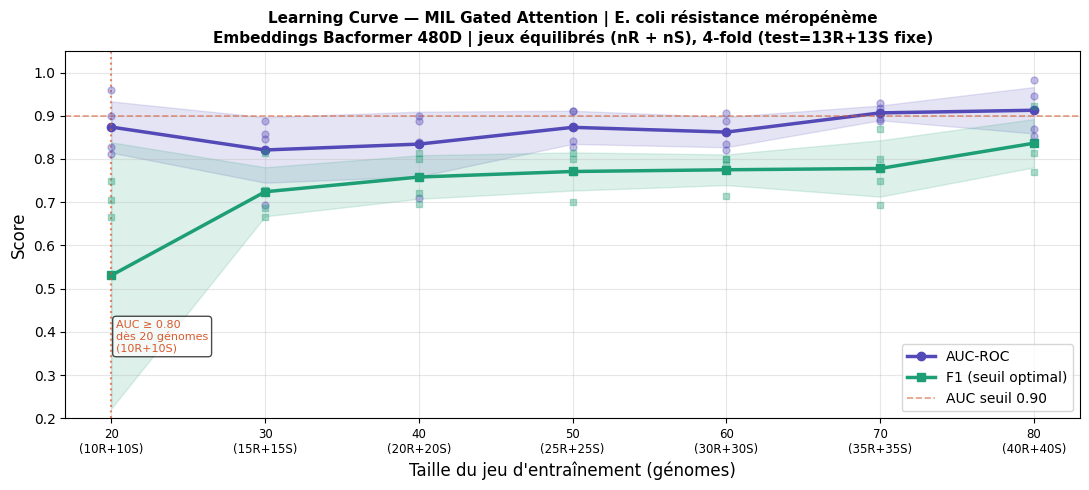

 Figure sauvegardée → learning_curve_MIL.png


In [33]:
# Visualisation

sizes_plot = [r["n_total"]     for r in lc_results]
auc_means  = [r["auc_mean"]    for r in lc_results]
auc_stds   = [r["auc_std"]     for r in lc_results]
f1_means   = [r["f1_mean"]  for r in lc_results]
f1_stds    = [r["f1_std"]   for r in lc_results]

COLOR_AUC = "#534AB7"
COLOR_F1  = "#1D9E75"

fig, ax = plt.subplots(figsize=(11, 5))

# AUC
ax.plot(sizes_plot, auc_means, marker="o", linewidth=2.5,
        color=COLOR_AUC, label="AUC-ROC")
ax.fill_between(sizes_plot,
                np.array(auc_means) - np.array(auc_stds),
                np.array(auc_means) + np.array(auc_stds),
                alpha=0.15, color=COLOR_AUC)

# F1
ax.plot(sizes_plot, f1_means, marker="s", linewidth=2.5,
        color=COLOR_F1, label="F1 (seuil optimal)")
ax.fill_between(sizes_plot,
                np.array(f1_means) - np.array(f1_stds),
                np.array(f1_means) + np.array(f1_stds),
                alpha=0.15, color=COLOR_F1)

# Points individuels (toutes les répétitions)
for r in lc_results:
    ax.scatter([r["n_total"]] * len(r["fold_aucs"]),   r["fold_aucs"],
               color=COLOR_AUC, alpha=0.35, s=25, zorder=5)
    ax.scatter([r["n_total"]] * len(r["fold_f1s"]), r["fold_f1s"],
               color=COLOR_F1,  alpha=0.35, s=25, zorder=5, marker="s")

# Ligne seuil AUC 0.9
ax.axhline(y=0.9, color="#D85A30", linestyle="--", alpha=0.6, linewidth=1.2,
           label="AUC seuil 0.90")

# Annotation premier palier AUC ≥ 0.80
first_good = next((i for i, a in enumerate(auc_means) if a >= 0.80), None)
if first_good is not None:
    s = sizes_plot[first_good]
    ax.axvline(x=s, color="#D85A30", linestyle=":", alpha=0.7, linewidth=1.5)
    ax.text(s + 0.3, 0.35,
            f"AUC ≥ 0.80\ndès {s} génomes\n({s//2}R+{s//2}S)",
            fontsize=8, color="#D85A30", va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

ax.set_xlabel("Taille du jeu d'entraînement (génomes)", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(
    "Learning Curve — MIL Gated Attention | E. coli résistance méropénème\n"
    "Embeddings Bacformer 480D | jeux équilibrés (nR + nS), 4-fold (test=13R+13S fixe)",
    fontsize=11, fontweight="bold"
)
ax.set_ylim(0.2, 1.05)
ax.set_xticks(sizes_plot)
ax.set_xticklabels([f"{s}\n({s//2}R+{s//2}S)" for s in sizes_plot], fontsize=8.5)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("learning_curve_MIL.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Figure sauvegardée → learning_curve_MIL.png")

In [25]:
print("=" * 60)
print("                      INTERPRÉTATION")
print("=" * 60)

best_auc_i = int(np.argmax(auc_means))
best_f1_i  = int(np.argmax(f1_means))
first_80   = next((i for i, a in enumerate(auc_means) if a >= 0.80), None)
first_90   = next((i for i, a in enumerate(auc_means) if a >= 0.90), None)

print(f"\n  Meilleure AUC : {auc_means[best_auc_i]:.3f} ± {auc_stds[best_auc_i]:.3f}")
print(f"    → {sizes_plot[best_auc_i]} génomes ({sizes_plot[best_auc_i]//2}R + {sizes_plot[best_auc_i]//2}S)")

print(f"\n  Meilleur F1   : {f1_means[best_f1_i]:.3f} ± {f1_stds[best_f1_i]:.3f}")
print(f"    → {sizes_plot[best_f1_i]} génomes ({sizes_plot[best_f1_i]//2}R + {sizes_plot[best_f1_i]//2}S)")

if first_80 is not None:
    s = sizes_plot[first_80]
    print(f"\n   AUC ≥ 0.80 atteinte dès {s} génomes ({s//2}R+{s//2}S)")

if first_90 is not None:
    s = sizes_plot[first_90]
    print(f"   AUC ≥ 0.90 atteinte dès {s} génomes ({s//2}R+{s//2}S)")

if first_80 is None:
    print("    AUC < 0.80 sur tous les paliers")

print("\n" + "=" * 60)

                      INTERPRÉTATION

  Meilleure AUC : 0.913 ± 0.054
    → 80 génomes (40R + 40S)

  Meilleur F1   : 0.836 ± 0.056
    → 80 génomes (40R + 40S)

   AUC ≥ 0.80 atteinte dès 20 génomes (10R+10S)
   AUC ≥ 0.90 atteinte dès 70 génomes (35R+35S)



In [26]:
# Fonction load_labels + load_pt
PT_DIR   = "embeddings_out"
GBK_DIR  = "genomes_gbff"
RGI_DIR  = "rgi_results"
LABELS_PATH = "matrice_listantibio_final.cleaned.list"
 
def load_labels(path):
    df = pd.read_csv(path, sep=None, engine="python")
    df["#Genome_ID_Genome_name"] = df["#Genome_ID_Genome_name"].astype(str)
    df["Resistant"]   = df["Resistant"].astype(int)
    df["Susceptible"] = df["Susceptible"].astype(int)
    return dict(zip(df["#Genome_ID_Genome_name"], df["Resistant"]))
 
def load_pt(fp):
    obj = torch.load(fp)
    gid = str(obj.get("genome_id", os.path.splitext(os.path.basename(fp))[0]))
    X   = obj["last_hidden_state"]
    if isinstance(X, np.ndarray):
        X = torch.from_numpy(X)
    if X.ndim == 3:
        X = X.squeeze(0)
    if X.ndim != 2:
        raise ValueError(f"{fp}: shape inattendue {tuple(X.shape)}")
    return gid, X.float()
 
# Charge labels + fichiers
id_to_y   = load_labels(LABELS_PATH)
all_files = sorted(glob.glob(os.path.join(PT_DIR, "*.pt")))
matched   = [fp for fp in all_files if load_pt(fp)[0] in id_to_y]
resistant_files  = [fp for fp in matched if id_to_y[load_pt(fp)[0]] == 1]
susceptible_files= [fp for fp in matched if id_to_y[load_pt(fp)[0]] == 0]
 
print(f"Labels chargés")
print(f"Total .pt matchés  : {len(matched)}")
print(f"Résistants         : {len(resistant_files)}")
print(f"Sensibles          : {len(susceptible_files)}")

Labels chargés
Total .pt matchés  : 907
Résistants         : 53
Sensibles          : 854


In [27]:
# IDs dans tes .pt
pt_ids  = set(os.path.splitext(os.path.basename(f))[0]
              for f in glob.glob("embeddings_out/*.pt"))

# IDs dans tes résultats RGI
rgi_ids = set(os.path.splitext(os.path.basename(f))[0]
              for f in glob.glob("rgi_results/*.txt"))

# IDs dans tes .gbff
gbff_ids = set(os.path.splitext(os.path.basename(f))[0]
               for f in glob.glob("genomes_gbff/*.gbff"))

print(f"IDs dans .pt   : {len(pt_ids)}")
print(f"IDs dans RGI   : {len(rgi_ids)}")
print(f"IDs dans .gbff : {len(gbff_ids)}")

IDs dans .pt   : 1066
IDs dans RGI   : 1066
IDs dans .gbff : 1066


In [28]:
# Parser le .gbff pour extraire les CDS dans l'ordre
from Bio import SeqIO

def load_gbff_annotation(genome_id):
    gbff_file = os.path.join(GBK_DIR, f"{genome_id}.gbff")
    if not os.path.exists(gbff_file):
        print(f"Fichier non trouvé : {gbff_file}")
        return None
    rows = []
    for record in SeqIO.parse(gbff_file, "genbank"):
        for feature in record.features:
            if feature.type != "CDS":
                continue
            rows.append({
                "contig":    record.id,
                "start":     int(feature.location.start),
                "end":       int(feature.location.end),
                "strand":    int(feature.location.strand),
                "locus_tag": feature.qualifiers.get("locus_tag", [""])[0],
                "gene":      feature.qualifiers.get("gene",      [""])[0],
                "product":   feature.qualifiers.get("product",   ["unknown"])[0],
            })
    if not rows:
        print(f"Aucun CDS trouvé")
        return None
    df = pd.DataFrame(rows).reset_index()
    return df.rename(columns={"index": "protein_index"})
 
# Test sur le premier génome disponible
sample_gid = load_pt(all_files[0])[0]
ann_test   = load_gbff_annotation(sample_gid)
 
if ann_test is not None:
    print(f".gbff chargé pour : {sample_gid}")
    print(f"   Nb CDS : {len(ann_test)}")
    print(ann_test[["protein_index","gene","product","start","end"]].head(10))
else:
    print("Problème — vérifie GBK_DIR et le nom des fichiers")

.gbff chargé pour : 1328432.3
   Nb CDS : 4665
   protein_index    gene                                            product  \
0              0    thrA  Bifunctional aspartokinase/homoserine dehydrog...   
1              1    thrB                                  Homoserine kinase   
2              2    thrC                                 Threonine synthase   
3              3                                       hypothetical protein   
4              4    yaaA  DNA-binding and peroxide stress resistance pro...   
5              5    alsT                    Amino-acid carrier protein AlsT   
6              6  talB_1                                    Transaldolase B   
7              7     mog                  Molybdopterin adenylyltransferase   
8              8    satP            Succinate-acetate/proton symporter SatP   
9              9                                       hypothetical protein   

   start    end  
0    335   2798  
1   2799   3732  
2   3732   5019  
3   5232   

In [29]:
# Parser les résultats RGI
 
def load_rgi_meropenem(genome_id):
    rgi_file = os.path.join(RGI_DIR, f"{genome_id}.txt")
    if not os.path.exists(rgi_file):
        return None

    df = pd.read_csv(rgi_file, sep="\t")

    # Garde Perfect + Strict uniquement
    df = df[df["Cut_Off"].isin(["Perfect", "Strict"])].copy()
    if len(df) == 0:
        return None

    # ── Filtre méropénème sur "Drug Class" ───
    mask = df["Drug Class"].str.lower().str.contains(
        "carbapenem|penem", na=False
    )
    df = df[mask].copy()
    if len(df) == 0:
        return None

    # Parse start/stop depuis Start/Stop
    df["rgi_start"] = df["Start"].astype(int)
    df["rgi_stop"]  = df["Stop"].astype(int)

    return df.reset_index(drop=True)

# Test sur le premier génome résistant
test_gid = load_pt(resistant_files[0])[0]
rgi_test = load_rgi_meropenem(test_gid)

print(f"Test RGI méropénème sur : {test_gid}")
if rgi_test is not None:
    print(f"   Nb gènes carbapénème détectés : {len(rgi_test)}")
    print(rgi_test[["Best_Hit_ARO", "Drug Class", "Cut_Off", "Best_Identities"]].to_string(index=False))
else:
    print("Aucun gène carbapénème trouvé")
    # Diagnostic — affiche tous les Drug Class trouvés
    df_all = pd.read_csv(os.path.join(RGI_DIR, f"{test_gid}.txt"), sep="\t")
    df_all = df_all[df_all["Cut_Off"].isin(["Perfect","Strict"])]
    print(f"\n   Tous les Drug Class trouvés :")
    for dc in df_all["Drug Class"].unique():
        print(f"     → {dc}")

Test RGI méropénème sur : 1328437.3
   Nb gènes carbapénème détectés : 3
                                                        Best_Hit_ARO                                                                                                                                                                                                        Drug Class Cut_Off  Best_Identities
                                                                marA fluoroquinolone antibiotic; monobactam; carbapenem; cephalosporin; glycylcycline; penicillin beta-lactam; tetracycline antibiotic; rifamycin antibiotic; phenicol antibiotic; disinfecting agents and antiseptics Perfect            100.0
                                                               KPC-2                                                                                                                                                     monobactam; carbapenem; cephalosporin; penicillin beta-lactam Perfect            100.0
Escherichia col

In [35]:
# top protéines annotées

N_BEST = 20   # ← change ici : 10, 15, 20, 25, 30, 35, 40

# Vérification
assert N_BEST in best_models, \
    f"Palier {N_BEST} non disponible. Paliers dispo : {list(best_models.keys())}"

model_best = GatedAttentionMIL(emb_dim, ATTN_DIM, HIDDEN, DROPOUT).to(device)
model_best.load_state_dict(best_models[N_BEST])
model_best.eval()

r_info = next(x for x in lc_results if x["n_per_class"] == N_BEST)
print(f" Modèle chargé : palier {N_BEST}R+{N_BEST}S = {2*N_BEST} génomes")
print(f"   AUC  : {r_info['auc_mean']:.3f} ± {r_info['auc_std']:.3f}")
print(f"   F1   : {r_info['f1_mean']:.3f} ± {r_info['f1_std']:.3f}")
print(f"   AUC par fold : {[round(a,3) for a in r_info['fold_aucs']]}")
print(f"   Meilleur fold : {r_info['best_fold']}\n")

# Full eval loader
full_dataset     = GenomeMILDataset(matched, id_to_y) #applique le modèle sur tous tes 907 génomes (pas juste le test) 
full_eval_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE,
                              shuffle=False, collate_fn=mil_collate)

def get_top_attention_with_annotation(model, loader, gbk_dir=GBK_DIR, top_k=10):
    model.eval()
    results = []
    with torch.no_grad():
        for Xpad, mask, y, gids in loader:
            Xpad, mask    = Xpad.to(device), mask.to(device)
            logits, alpha = model(Xpad, mask)
            probs         = torch.sigmoid(logits).cpu().numpy()

            for i, gid in enumerate(gids):
                n_prot  = int(mask[i].sum().item())
                attn    = alpha[i, :n_prot].cpu().numpy()
                top_idx = np.argsort(attn)[::-1][:top_k]

                entropy     = float(-np.sum(attn * np.log(attn + 1e-12)))
                max_entropy = float(np.log(n_prot))

                ann = load_gbff_annotation(gid)
                top_proteins = []
                for rank, idx in enumerate(top_idx, 1):
                    entry = {
                        "rank":             rank,
                        "protein_index":    int(idx),
                        "attention_weight": float(attn[idx]),
                        "attention_pct":    float(100 * attn[idx] / attn.sum()),
                    }
                    if ann is not None and idx < len(ann):
                        row = ann.iloc[idx]
                        entry["gene"]      = row.get("gene",      None) or "—"
                        entry["product"]   = row.get("product",   None) or "—"
                        entry["locus_tag"] = row.get("locus_tag", None) or "—"
                    else:
                        entry["gene"]      = "?"
                        entry["product"]   = "?"
                        entry["locus_tag"] = "?"
                    top_proteins.append(entry)

                results.append({
                    "genome_id":        gid,
                    "true_label":       int(y[i].item()),
                    "predicted_prob":   float(probs[i]),
                    "predicted_label":  int(probs[i] >= 0.5),
                    "correct":          int(y[i].item()) == int(probs[i] >= 0.5),
                    "n_proteins":       n_prot,
                    "attn_entropy_pct": float(entropy / max_entropy) if max_entropy > 0 else 1.0,
                    "top_proteins":     top_proteins,
                })
    return results

top_attn_ann  = get_top_attention_with_annotation(model_best, full_eval_loader, top_k=10)
resistant_ann = [r for r in top_attn_ann if r["true_label"] == 1]
correct_R     = sum(1 for r in resistant_ann if r["correct"])

# Affichage
print(f"Palier {N_BEST}R+{N_BEST}S — génomes RÉSISTANTS ({len(resistant_ann)})")
print(f"Prédictions correctes : {correct_R}/{len(resistant_ann)} "
      f"({correct_R/len(resistant_ann):.1%})\n")

for r in resistant_ann:
    icon = "CORRECT" if r["correct"] else "NOT CORRECT"
    print(f"\n{'='*85}")
    print(f"{icon}  Genome : {r['genome_id']}  |  "
          f"P(resistant)={r['predicted_prob']:.3f}  |  "
          f"{r['n_proteins']} protéines  |  "
          f"Entropie : {r['attn_entropy_pct']:.1%}")
    print(f"{'='*85}")
    print(f"{'Rang':>4} | {'Idx':>6} | {'Poids':>10} | {'% total':>7} | "
          f"{'Gène':>12} | Produit")
    print(f"{'-'*4}-+-{'-'*6}-+-{'-'*10}-+-{'-'*7}-+-{'-'*12}-+-{'-'*40}")
    for p in r["top_proteins"]:
        print(
            f"{p['rank']:>4} | "
            f"{p['protein_index']:>6} | "
            f"{p['attention_weight']:.8f} | "
            f"{p['attention_pct']:>6.2f}% | "
            f"{p['gene']:>12} | "
            f"{str(p['product'])[:50]}"
        )

# Export CSV
rows = []
for r in top_attn_ann:
    for p in r["top_proteins"]:
        rows.append({
            "genome_id":        r["genome_id"],
            "true_label":       r["true_label"],
            "predicted_prob":   round(r["predicted_prob"], 4),
            "correct":          r["correct"],
            "n_proteins":       r["n_proteins"],
            "attn_entropy_pct": round(r["attn_entropy_pct"], 4),
            **p
        })

df_ann = pd.DataFrame(rows)
#df_ann.to_csv(f"top_attention_{N_BEST}R_annotated.csv", index=False)
#print(f"\n Export de top_attention_{N_BEST}R_annotated.csv ({len(df_ann)} lignes)")

display(
    df_ann[df_ann["true_label"] == 1]
    .sort_values(["genome_id", "rank"])
    .reset_index(drop=True)
)

 Modèle chargé : palier 20R+20S = 40 génomes
   AUC  : 0.834 ± 0.075
   F1   : 0.758 ± 0.050
   AUC par fold : [0.888, 0.899, 0.71, 0.84]
   Meilleur fold : 2

Palier 20R+20S — génomes RÉSISTANTS (53)
Prédictions correctes : 52/53 (98.1%)


CORRECT  Genome : 1328437.3  |  P(resistant)=0.527  |  5202 protéines  |  Entropie : 99.9%
Rang |    Idx |      Poids | % total |         Gène | Produit
-----+--------+------------+---------+--------------+-----------------------------------------
   1 |   4990 | 0.00033064 |   0.03% |         yigL | Pyridoxal phosphate phosphatase YigL
   2 |   3425 | 0.00031833 |   0.03% |         dtpB | Dipeptide and tripeptide permease B
   3 |   2765 | 0.00030539 |   0.03% |         spaP | Surface presentation of antigens protein SpaP
   4 |   5137 | 0.00029797 |   0.03% |            — | hypothetical protein
   5 |   1839 | 0.00029657 |   0.03% |         fliH | Flagellar assembly protein FliH
   6 |   2753 | 0.00029523 |   0.03% |       rcsB_2 | Transcriptional

,genome_id,true_label,predicted_prob,correct,n_proteins,attn_entropy_pct,rank,protein_index,attention_weight,attention_pct,gene,product,locus_tag
0,1328437.3,1,0.5269,True,5202,0.9989,1,4990,0.000331,0.033064,yigL,Pyridoxal phosphate phosphatase YigL,PABACNKJ_05077
1,1328437.3,1,0.5269,True,5202,0.9989,2,3425,0.000318,0.031833,dtpB,Dipeptide and tripeptide permease B,PABACNKJ_03493
2,1328437.3,1,0.5269,True,5202,0.9989,3,2765,0.000305,0.030539,spaP,Surface presentation of antigens protein SpaP,PABACNKJ_02825
3,1328437.3,1,0.5269,True,5202,0.9989,4,5137,0.000298,0.029797,—,hypothetical protein,PABACNKJ_05231
4,1328437.3,1,0.5269,True,5202,0.9989,5,1839,0.000297,0.029657,fliH,Flagellar assembly protein FliH,PABACNKJ_01874
...,...,...,...,...,...,...,...,...,...,...,...,...,...
525,562.91162,1,0.5274,True,4737,0.9989,6,973,0.000320,0.031960,yaeQ,putative protein YaeQ,MFDGIJDN_00996
526,562.91162,1,0.5274,True,4737,0.9989,7,415,0.000319,0.031924,—,hypothetical protein,MFDGIJDN_00430
527,562.91162,1,0.5274,True,4737,0.9989,8,3686,0.000319,0.031904,—,hypothetical protein,MFDGIJDN_03774
528,562.91162,1,0.5274,True,4737,0.9989,9,1001,0.000319,0.031869,—,hypothetical protein,MFDGIJDN_01031


In [36]:
# top protéines annotées

N_BEST = 40   # ← change ici : 10, 15, 20, 25, 30, 35, 40

# Vérification
assert N_BEST in best_models, \
    f"Palier {N_BEST} non disponible. Paliers dispo : {list(best_models.keys())}"

model_best = GatedAttentionMIL(emb_dim, ATTN_DIM, HIDDEN, DROPOUT).to(device)
model_best.load_state_dict(best_models[N_BEST])
model_best.eval()

r_info = next(x for x in lc_results if x["n_per_class"] == N_BEST)
print(f" Modèle chargé : palier {N_BEST}R+{N_BEST}S = {2*N_BEST} génomes")
print(f"   AUC  : {r_info['auc_mean']:.3f} ± {r_info['auc_std']:.3f}")
print(f"   F1   : {r_info['f1_mean']:.3f} ± {r_info['f1_std']:.3f}")
print(f"   AUC par fold : {[round(a,3) for a in r_info['fold_aucs']]}")
print(f"   Meilleur fold : {r_info['best_fold']}\n")

# Full eval loader
full_dataset     = GenomeMILDataset(matched, id_to_y) #applique le modèle sur tous tes 907 génomes (pas juste le test)
full_eval_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE,
                              shuffle=False, collate_fn=mil_collate)

def get_top_attention_with_annotation(model, loader, gbk_dir=GBK_DIR, top_k=10):
    model.eval()
    results = []
    with torch.no_grad():
        for Xpad, mask, y, gids in loader:
            Xpad, mask    = Xpad.to(device), mask.to(device)
            logits, alpha = model(Xpad, mask)
            probs         = torch.sigmoid(logits).cpu().numpy()

            for i, gid in enumerate(gids):
                n_prot  = int(mask[i].sum().item())
                attn    = alpha[i, :n_prot].cpu().numpy()
                top_idx = np.argsort(attn)[::-1][:top_k]

                entropy     = float(-np.sum(attn * np.log(attn + 1e-12)))
                max_entropy = float(np.log(n_prot))

                ann = load_gbff_annotation(gid)
                top_proteins = []
                for rank, idx in enumerate(top_idx, 1):
                    entry = {
                        "rank":             rank,
                        "protein_index":    int(idx),
                        "attention_weight": float(attn[idx]),
                        "attention_pct":    float(100 * attn[idx] / attn.sum()),
                    }
                    if ann is not None and idx < len(ann):
                        row = ann.iloc[idx]
                        entry["gene"]      = row.get("gene",      None) or "—"
                        entry["product"]   = row.get("product",   None) or "—"
                        entry["locus_tag"] = row.get("locus_tag", None) or "—"
                    else:
                        entry["gene"]      = "?"
                        entry["product"]   = "?"
                        entry["locus_tag"] = "?"
                    top_proteins.append(entry)

                results.append({
                    "genome_id":        gid,
                    "true_label":       int(y[i].item()),
                    "predicted_prob":   float(probs[i]),
                    "predicted_label":  int(probs[i] >= 0.5),
                    "correct":          int(y[i].item()) == int(probs[i] >= 0.5),
                    "n_proteins":       n_prot,
                    "attn_entropy_pct": float(entropy / max_entropy) if max_entropy > 0 else 1.0,
                    "top_proteins":     top_proteins,
                })
    return results

top_attn_ann  = get_top_attention_with_annotation(model_best, full_eval_loader, top_k=10)
resistant_ann = [r for r in top_attn_ann if r["true_label"] == 1]
correct_R     = sum(1 for r in resistant_ann if r["correct"])

# Affichage
print(f"Palier {N_BEST}R+{N_BEST}S — génomes RÉSISTANTS ({len(resistant_ann)})")
print(f"Prédictions correctes : {correct_R}/{len(resistant_ann)} "
      f"({correct_R/len(resistant_ann):.1%})\n")

for r in resistant_ann:
    icon = "CORRECT" if r["correct"] else "NOT CORRECT"
    print(f"\n{'='*85}")
    print(f"{icon}  Genome : {r['genome_id']}  |  "
          f"P(resistant)={r['predicted_prob']:.3f}  |  "
          f"{r['n_proteins']} protéines  |  "
          f"Entropie : {r['attn_entropy_pct']:.1%}")
    print(f"{'='*85}")
    print(f"{'Rang':>4} | {'Idx':>6} | {'Poids':>10} | {'% total':>7} | "
          f"{'Gène':>12} | Produit")
    print(f"{'-'*4}-+-{'-'*6}-+-{'-'*10}-+-{'-'*7}-+-{'-'*12}-+-{'-'*40}")
    for p in r["top_proteins"]:
        print(
            f"{p['rank']:>4} | "
            f"{p['protein_index']:>6} | "
            f"{p['attention_weight']:.8f} | "
            f"{p['attention_pct']:>6.2f}% | "
            f"{p['gene']:>12} | "
            f"{str(p['product'])[:50]}"
        )

# Export CSV
rows = []
for r in top_attn_ann:
    for p in r["top_proteins"]:
        rows.append({
            "genome_id":        r["genome_id"],
            "true_label":       r["true_label"],
            "predicted_prob":   round(r["predicted_prob"], 4),
            "correct":          r["correct"],
            "n_proteins":       r["n_proteins"],
            "attn_entropy_pct": round(r["attn_entropy_pct"], 4),
            **p
        })

df_ann = pd.DataFrame(rows)
#df_ann.to_csv(f"top_attention_{N_BEST}R_annotated.csv", index=False)
#print(f"\n Export de top_attention_{N_BEST}R_annotated.csv ({len(df_ann)} lignes)")

display(
    df_ann[df_ann["true_label"] == 1]
    .sort_values(["genome_id", "rank"])
    .reset_index(drop=True)
)

 Modèle chargé : palier 40R+40S = 80 génomes
   AUC  : 0.913 ± 0.054
   F1   : 0.836 ± 0.056
   AUC par fold : [0.852, 0.982, 0.87, 0.947]
   Meilleur fold : 2

Palier 40R+40S — génomes RÉSISTANTS (53)
Prédictions correctes : 51/53 (96.2%)


CORRECT  Genome : 1328437.3  |  P(resistant)=0.869  |  5202 protéines  |  Entropie : 34.4%
Rang |    Idx |      Poids | % total |         Gène | Produit
-----+--------+------------+---------+--------------+-----------------------------------------
   1 |   4431 | 0.46754447 |  46.75% |         traC | Protein TraC
   2 |   4490 | 0.06814689 |   6.81% |       otnK_1 | 3-oxo-tetronate kinase
   3 |   3073 | 0.04108637 |   4.11% |            — | hypothetical protein
   4 |   4293 | 0.02875229 |   2.88% |            — | hypothetical protein
   5 |   3072 | 0.02428777 |   2.43% |            — | hypothetical protein
   6 |   4564 | 0.02199478 |   2.20% |            — | hypothetical protein
   7 |   4329 | 0.02023640 |   2.02% |            — | hypothetical

,genome_id,true_label,predicted_prob,correct,n_proteins,attn_entropy_pct,rank,protein_index,attention_weight,attention_pct,gene,product,locus_tag
0,1328437.3,1,0.8691,True,5202,0.3443,1,4431,0.467544,46.754452,traC,Protein TraC,PABACNKJ_04510
1,1328437.3,1,0.8691,True,5202,0.3443,2,4490,0.068147,6.814690,otnK_1,3-oxo-tetronate kinase,PABACNKJ_04569
2,1328437.3,1,0.8691,True,5202,0.3443,3,3073,0.041086,4.108637,—,hypothetical protein,PABACNKJ_03136
3,1328437.3,1,0.8691,True,5202,0.3443,4,4293,0.028752,2.875230,—,hypothetical protein,PABACNKJ_04372
4,1328437.3,1,0.8691,True,5202,0.3443,5,3072,0.024288,2.428777,—,hypothetical protein,PABACNKJ_03135
...,...,...,...,...,...,...,...,...,...,...,...,...,...
525,562.91162,1,0.8560,True,4737,0.4288,6,56,0.043287,4.328662,gdx_1,Guanidinium exporter,MFDGIJDN_00057
526,562.91162,1,0.8560,True,4737,0.4288,7,46,0.040682,4.068198,pndA_1,Protein PndA,MFDGIJDN_00047
527,562.91162,1,0.8560,True,4737,0.4288,8,4612,0.037854,3.785351,ccdB,Toxin CcdB,MFDGIJDN_04727
528,562.91162,1,0.8560,True,4737,0.4288,9,2147,0.029283,2.928272,—,hypothetical protein,MFDGIJDN_02199
